In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.special import factorial

# N-particle Structure Factor

In [2]:
def debye_waller(q, m, B, omegas, ell, N):
    # result=0
    # for nu in range(N-1):
    #     result+= B[nu, ell]*np.conjugate(B[nu, ell])/omegas[nu]
    result = np.sum(B[:, ell]*np.conjugate(B[:, ell])/omegas)* q**2/(4*m)
    return result

In [3]:
def combos_helper_function_diag(j_vector, B, omegas, N, ell):
    '''
    For each set of j, calculate the product in the structure factor in the diagonal term
    '''
    # tot=1
    # for r in range(N):
    #     if j_vector[r]!=0:
    #         tot*=1/factorial(j_vector[r])*(B[ell][r]*np.conjugate(B[ell][r])/omegas[r])**j_vector[r]
    ind = np.nonzero(np.array(j_vector))
    tot = np.prod(1/factorial(j_vector[ind])*(B[ind, ell]*np.conjugate(B[ind, ell])/omegas[ind])**j_vector[ind])
    return tot

In [4]:
def combos_helper_function_offdiag(j_vector, B, omegas, N, ell, ell_prime):
    # tot=1
    # for r in range(N):
    #     if j_vector[r]!=0:
    #         tot*=1/factorial(j_vector[r])*(B[ell][r]*np.conjugate(B[ell_prime][r])/omegas[r])**j_vector[r]
    ind = np.nonzero(np.array(j_vector))
    tot = np.prod(1/factorial(j_vector[ind])*(B[ind, ell]*np.conjugate(B[ind, ell_prime])/omegas[ind])**j_vector[ind])
    return tot

In [5]:
def diagonal_C_singleCombo(q, m, omegas, n, j_vector,N,ell,B, V=1):
    '''
    For each set of j, calculate one term in the summation of C_ll
    '''
    j_vector = np.array(j_vector)
    expDebyeWaller = np.exp(-2*debye_waller(q, m, B, omegas, ell, N))
    c=expDebyeWaller/V * (q**2/(2*m))**n * 2*np.pi * combos_helper_function_diag(j_vector, B, omegas, N, ell)
    return c

In [6]:
def offDiagonal_C_singleCombo(q, m, omegas, n, j_vector, N ,ell, ell_prime, B , V=1, a=0.001):
    j_vector = np.array(j_vector)
    expDebyeWaller = np.exp(-debye_waller(q, m, B, omegas, ell, N)-debye_waller(q, m, B, omegas, ell_prime, N))
    c=expDebyeWaller/V * (q**2/(2*m))**n * 2*np.pi*combos_helper_function_offdiag(j_vector, B, omegas, N, ell, ell_prime)
    c = c*np.cos(q*a*(ell-ell_prime))
    return c

In [7]:
def allj_One_n(n, N, end=[]):
    # given n, N, find all possible sets of j
    combos=[]
    if N==1:
        for row in end:
            combos.append([n-sum(row)]+row)
        return combos
    if len(end)==0:
        for value in range(n+1):
            combos.append([value])
        return allj_One_n(n, N-1, combos)
    for row in end:
        for j in range(n-sum(row)+1):
            combos.append([j]+row)
    return allj_One_n(n, N-1, combos)       

In [8]:
def StructureFactorIntegral_singleCombo(q, m, omegas, n, j, N ,B , V=1, a=0.001, A=1):
    # For each set of j, sum all C_ll terms over N
    tot=np.zeros(len(q),dtype=np.complex128)
    for ell in range(N):
        for ell_prime in range(N):
            if ell==ell_prime:
                tot+=diagonal_C_singleCombo(q, m, omegas, n, j,N,ell,B, V)
            else:
                tot+=offDiagonal_C_singleCombo(q, m, omegas, n, j, N ,ell, ell_prime, B , V, a)
    return A**2 * tot

In [9]:
def StructureFactorIntegral_singleCombo_diag(q, m, omegas, n, j, N ,B , V=1, a=0.001, A=1):
    # For each set of j, sum all C_ll terms over N
    tot=np.zeros(len(q),dtype=np.complex128)
    for ell in range(N):
        tot+=diagonal_C_singleCombo(q, m, omegas, n, j, N,ell,B, V)
    return A**2 * tot

In [10]:
def StructureFactorIntegral_allj(q, m, omegas, n, N ,B , V=1, a=0.001, A=1):
    # sum over all sets of j
    j_combos = allj_One_n(n, N-1)
    tot=np.zeros(len(q),dtype=np.complex128)
    for j in j_combos:
        tot+= StructureFactorIntegral_singleCombo(q, m, omegas, n, j, N ,B , V, a, A)
    return tot

In [11]:
def StructureFactorIntegral_allj_diag(q, m, omegas, n, N ,B , V=1, a=0.001, A=1):
    # sum over all sets of j
    j_combos = allj_One_n(n, N-1)
    tot=np.zeros(len(q),dtype=np.complex128)
    for j in j_combos:
        tot+= StructureFactorIntegral_singleCombo_diag(q, m, omegas, n, j, N ,B , V, a, A)
    return tot

In [12]:
m=26161e3 # keV
omegaNaught = 10e-6 # keV, correpsonds to maximum energy of 20 meV
# N=10

# mat = np.arange(1, N+1) * np.arange(1, N).reshape(N-1,-1)
# B = np.exp(1j*2*np.pi*mat/N)/np.sqrt(N)
# omegas = np.sqrt(2*(1-np.cos(2*np.pi*np.arange(1, N)/N)))*omegaNaught

In [13]:
# B, omegas

In [14]:
# K_param= np.zeros((N,N))
# K_param[np.arange(N),np.arange(N)] = 2 * omegaNaught**2
# K_param[np.arange(1,N),np.arange(N-1)] = - omegaNaught**2
# K_param[np.arange(N-1),np.arange(1,N)] = - omegaNaught**2
# K_param[0,N-1], K_param[N-1, 0] = - omegaNaught**2, - omegaNaught**2

# K_param*1e10

In [15]:
# omegas, B= np.linalg.eig(K_param)
# B=B.T
# omegas = np.array([np.sqrt(omegas[i]) for i in range(N)])
# print(B)
# print(omegas)

In [16]:
# SFI_params = {'m':m, 'B':B, 'ome':omegas, 'V':5*N, "A":10, "a":2*np.pi/2.28, 'N':N}

In [17]:
log_q_values = np.linspace(-1, np.log10(300), 8000) 
q_values = 10**log_q_values # keV

In [18]:
# q = q_values[10:12]

# StructureFactorIntegral_allj(q, SFI_params['m'], SFI_params['ome'], n, SFI_params['N'] 
#                                       ,SFI_params['B'] , SFI_params['V'], SFI_params['a'], SFI_params['A'])

In [19]:
SFI_allj_allN = []
SFI_allj_allN_diag = []

N_list = np.array([3,10,20])

for N in N_list: 
    mat = np.arange(1, N+1) * np.arange(1, N).reshape(N-1,-1)
    B = np.exp(1j*2*np.pi*mat/N)/np.sqrt(N)
    omegas = np.sqrt(2*(1-np.cos(2*np.pi*np.arange(1, N)/N)))*omegaNaught
    SFI_params = {'m':m, 'B':B, 'ome':omegas, 'V':5*N, "A":10, "a":2*np.pi/2.28, 'N':N}

    SFI_allj =[]
    SFI_allj_diag =[]
    for n in range(1,3):
        SFI_allj.append(np.real(StructureFactorIntegral_allj(q_values, SFI_params['m'], SFI_params['ome'], n, SFI_params['N']
                                        ,SFI_params['B'] , SFI_params['V'], SFI_params['a'], SFI_params['A'])))
        SFI_allj_diag.append(np.real(StructureFactorIntegral_allj_diag(q_values, SFI_params['m'], SFI_params['ome'], n, SFI_params['N']
                                        ,SFI_params['B'] , SFI_params['V'], SFI_params['a'], SFI_params['A'])))
    SFI_allj_allN.append(SFI_allj)
    SFI_allj_allN_diag.append(SFI_allj_diag)
SFI_allj_allN = np.array(SFI_allj_allN)
SFI_allj_allN_diag = np.array(SFI_allj_allN_diag)

KeyboardInterrupt: 

In [ ]:
np.array(SFI_allj_allN).shape

(3, 2, 8000)

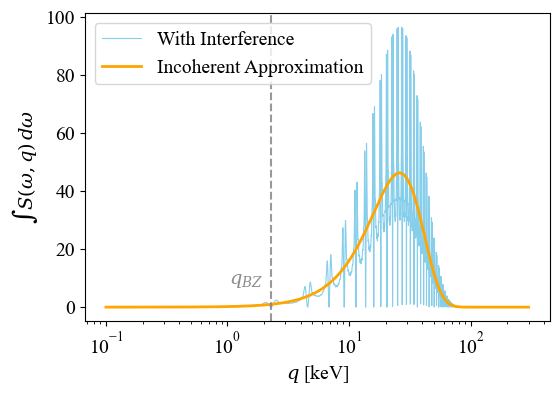

In [ ]:
plt.rcParams['font.family'] = "Times New Roman"
plt.rcParams['mathtext.fontset'] = "dejavuserif"

plt.figure(figsize=(6,4))
plt.plot(q_values,SFI_allj_allN[1,0], linewidth=0.8,label="With Interference", color='skyblue')
plt.plot(q_values,SFI_allj_allN_diag[1,0], linewidth=2, label="Incoherent Approximation", color='orange')
plt.xscale('log')
plt.ylabel(r"$\int S(\omega,q)\, d\omega$", size = 14)
plt.xlabel('$q$ [keV]', size = 14)
plt.tick_params(axis='both', labelsize=14)
plt.axvline(2*np.pi/SFI_params['a'], color='gray', linestyle='--',alpha=0.8)
plt.text(2*np.pi/SFI_params['a']*.45, 8, '$q_{BZ}$', color='gray', alpha=0.9, size=14)
# plt.yticks(np.arange(.5, .97, .05), [0.5, '',0.6, '', 0.7,'',0.8,'',0.9,''])


plt.legend(fontsize=14,loc='upper left')
plt.savefig("10SiteLattice_1phonon.png",dpi=200, bbox_inches='tight' )
plt.show()

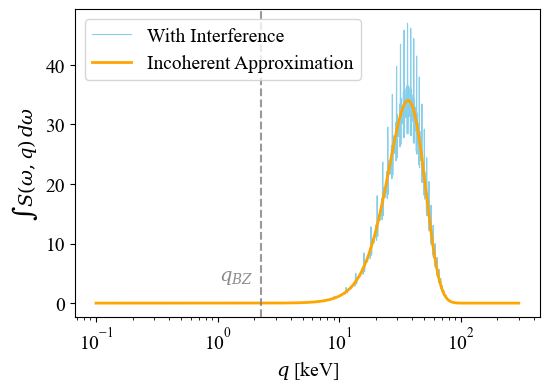

In [ ]:
plt.rcParams['font.family'] = "Times New Roman"
plt.rcParams['mathtext.fontset'] = "dejavuserif"

plt.figure(figsize=(6,4))
plt.plot(q_values,SFI_allj_allN[1,1], linewidth=0.8,label="With Interference", color='skyblue')
plt.plot(q_values,SFI_allj_allN_diag[1,1], linewidth=2, label="Incoherent Approximation", color='orange')
plt.xscale('log')
plt.ylabel(r"$\int S(\omega,q)\, d\omega$", size = 14)
plt.xlabel('$q$ [keV]', size = 14)
plt.tick_params(axis='both', labelsize=14)
plt.axvline(2*np.pi/SFI_params['a'], color='gray', linestyle='--',alpha=0.8)
plt.text(2*np.pi/SFI_params['a']*.45, 3.8, '$q_{BZ}$', color='gray', alpha=0.9, size=14)

# plt.yticks(np.arange(.5, .97, .05), [0.5, '',0.6, '', 0.7,'',0.8,'',0.9,''])


plt.legend(fontsize=14,loc='upper left')
plt.savefig("10SiteLattice_2phonons.png",dpi=200, bbox_inches='tight' )
plt.show()

In [ ]:
# plt.plot(q_values, SFI_allj_allN[0,0],label=f"N = {N_list[0]}, n = 1")
# plt.plot(q_values, SFI_allj_allN[1,0],label="N = 5, n = 1")
# plt.plot(q_values, SFI_allj_allN[2,0],label="N = 10, n = 1")
# plt.xscale('log')
# plt.legend()
# plt.show()

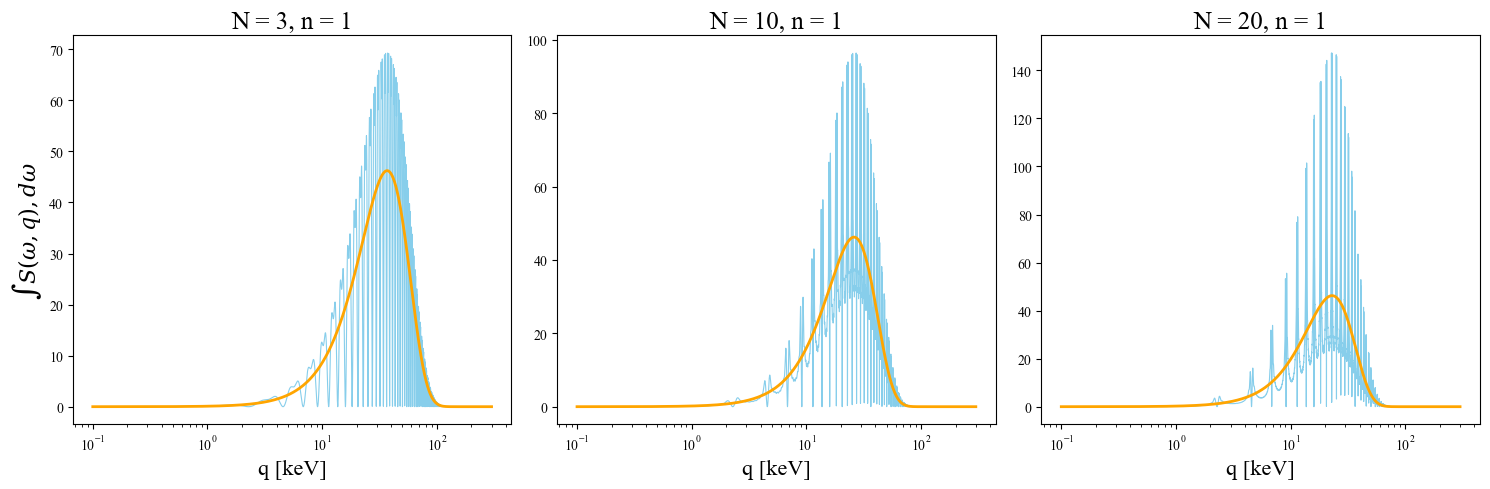

In [ ]:
fig, axes = plt.subplots(1,3,figsize=(15,5), sharex=True)

for i in range(3):
    axes[i].plot(q_values, SFI_allj_allN[i,0],linewidth=0.8,label="With Interference", color='skyblue')
    axes[i].plot(q_values, SFI_allj_allN_diag[i,0],linewidth=2, label="Incoherent Approximation", color='orange')
    axes[i].set_title(f"N = {N_list[i]}, n = 1", fontsize=18)
    axes[i].set_xlabel('q [keV]',size=16)
    axes[i].set_xscale('log')
    if i == 0:
        axes[i].set_ylabel(r"$\int S(\omega,q), d\omega$", size=16)
plt.tight_layout()
plt.savefig('different_sites_of_lattice',dpi=200, bbox_inches='tight')


In [ ]:
q_values = np.linspace(0, 2*np.pi/SFI_params['a'], 500)

SFI_allj_allN = []
SFI_allj_allN_diag = []

N_list = np.array([3,10,20])

for N in N_list: 
    mat = np.arange(1, N+1) * np.arange(1, N).reshape(N-1,-1)
    B = np.exp(1j*2*np.pi*mat/N)/np.sqrt(N)
    omegas = np.sqrt(2*(1-np.cos(2*np.pi*np.arange(1, N)/N)))*omegaNaught
    SFI_params = {'m':m, 'B':B, 'ome':omegas, 'V':5*N, "A":10, "a":2*np.pi/2.28, 'N':N}

    SFI_allj =[]
    SFI_allj_diag =[]
    for n in range(1,3):
        SFI_allj.append(np.real(StructureFactorIntegral_allj(q_values, SFI_params['m'], SFI_params['ome'], n, SFI_params['N']
                                        ,SFI_params['B'] , SFI_params['V'], SFI_params['a'], SFI_params['A'])))
        SFI_allj_diag.append(np.real(StructureFactorIntegral_allj_diag(q_values, SFI_params['m'], SFI_params['ome'], n, SFI_params['N']
                                        ,SFI_params['B'] , SFI_params['V'], SFI_params['a'], SFI_params['A'])))
    SFI_allj_allN.append(SFI_allj)
    SFI_allj_allN_diag.append(SFI_allj_diag)
SFI_allj_allN = np.array(SFI_allj_allN)
SFI_allj_allN_diag = np.array(SFI_allj_allN_diag)

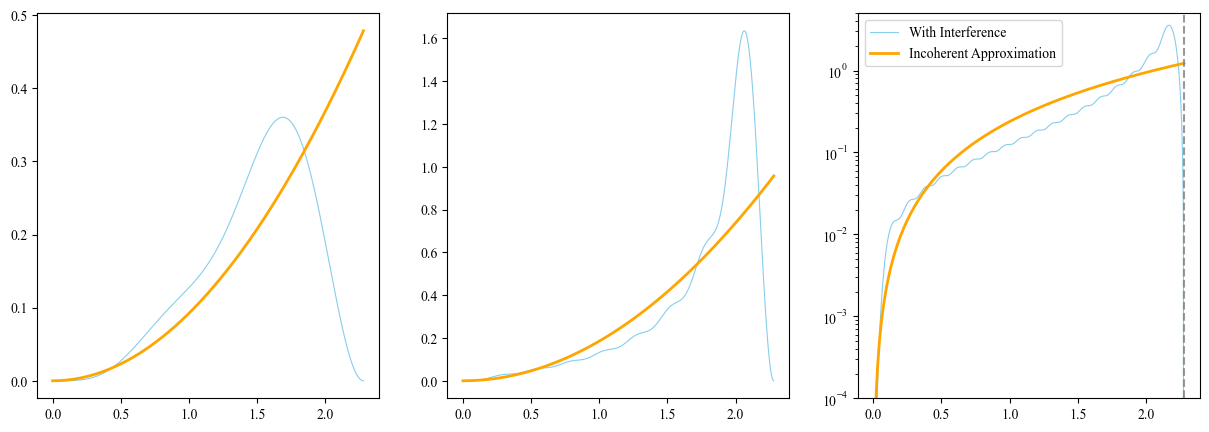

In [ ]:
fig, axes = plt.subplots(1,3,figsize=(15,5), sharex=True)

for i in range(3):
    axes[i].plot(q_values, SFI_allj_allN[i,0],linewidth=0.8,label="With Interference", color='skyblue')
    axes[i].plot(q_values, SFI_allj_allN_diag[i,0],linewidth=2, label="Incoherent Approximation", color='orange')
plt.yscale('log')
# plt.xlim(q_values[0], 2*np.pi/SFI_params['a'])
plt.ylim(1e-4, 5)
plt.axvline(2*np.pi/SFI_params['a'], color='gray', linestyle='--',alpha=0.8)
plt.legend()
plt.show()

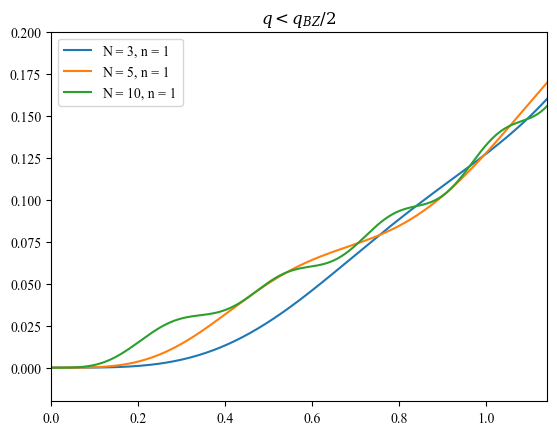

In [ ]:
fig, axes = plt.subplots(1,3,figsize=(15,5), sharex=True)

for i in range(3):
    axes[i].plot(q_values, SFI_allj_allN[i,0],linewidth=0.8,label="With Interference", color='skyblue')
    axes[i].plot(q_values, SFI_allj_allN_diag[i,0],linewidth=2, label="Incoherent Approximation", color='orange')
# plt.yscale('log')
plt.xlim(q_values[0], np.pi/SFI_params['a'])
plt.ylim(-0.02, 0.2)
# plt.axvline(2*np.pi/SFI_params['a'], color='gray', linestyle='--',alpha=0.8)
plt.legend()
plt.title(r'$q<q_{BZ}/2$')
plt.show()